# Sentiment Scoring — Baseline 1: Financial Lexicon

Dictionary-based hawkish/dovish sentiment score computed from a hand-built financial lexicon (`HAWKISH_TERMS`, `DOVISH_TERMS` in `src/sentiment.py`), following the standard central-bank-communication scoring convention: score = (hawkish phrase count − dovish phrase count) / total words.

In [1]:
import sys
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\hp\Desktop\rbi-sentiment-market-forecast


## Load the cleaned master dataset

In [2]:
from paths import MASTER_TEXT_CSV

master = pd.read_csv(MASTER_TEXT_CSV, parse_dates=["listed_date"])
print(f"Loaded {len(master)} documents")
master.head()

Loaded 163 documents


,prid,fin_year,listed_date,doc_type,title,text,char_length,source
0,36654,2016-2017,2016-04-05,governor_statement,"Statement by Dr. Raghuram Rajan, Governor, Res...","Aug 18, 2026 Web Information Manager Accessibi...",195,html
1,37151,2016-2017,2016-06-07,governor_statement,"Statement by Dr. Raghuram Rajan, Governor, Res...","Aug 18, 2026 Web Information Manager Accessibi...",195,html
2,37734,2016-2017,2016-08-09,governor_statement,"Statement by Dr. Raghuram Rajan, Governor, Res...","Aug 18, 2026 Web Information Manager Accessibi...",195,html
3,37735,2016-2017,2016-08-09,governor_statement,Governor’s Opening Statement to the Post-Polic...,"August 9, 2016 Governor’s Opening Statement to...",4662,pdf
4,38224,2016-2017,2016-10-04,resolution,Resolution of the Monetary Policy Committee (M...,"October 04, 2016 Fourth Bi-monthly Monetary Po...",9715,pdf


## Score every document

In [3]:
from sentiment import score_dataframe

scored = score_dataframe(master)
scored[["listed_date", "doc_type", "hawkish_count", "dovish_count", "lexicon_score_x1000"]].head(10)

,listed_date,doc_type,hawkish_count,dovish_count,lexicon_score_x1000
0,2016-04-05,governor_statement,0.0,0.0,0.000000
1,2016-06-07,governor_statement,0.0,0.0,0.000000
2,2016-08-09,governor_statement,0.0,0.0,0.000000
3,2016-08-09,governor_statement,0.0,2.0,-2.525253
4,2016-10-04,resolution,0.0,5.0,-3.331113
5,2016-10-18,minutes,2.0,10.0,-2.547771
6,2016-12-07,resolution,5.0,4.0,0.413907
7,2016-12-21,minutes,5.0,5.0,0.000000
8,2017-02-08,resolution,2.0,5.0,-1.378043
9,2017-02-22,minutes,3.0,12.0,-1.798202


## Validation

Scored against two documents with unambiguous, publicly known policy stances: the September 2022 Resolution (50bps hike, amid the inflation shock) and the February/April 2021 Resolutions (pandemic-era accommodation).

In [4]:
check = scored[scored["listed_date"].between("2022-09-01", "2022-10-05") & (scored["doc_type"] == "resolution")]
print("Sep 2022 Resolution (expect hawkish, i.e. positive score):")
print(check[["listed_date", "hawkish_count", "dovish_count", "lexicon_score_x1000"]])

check2 = scored[scored["listed_date"].between("2021-01-01", "2021-06-01") & (scored["doc_type"] == "resolution")]
print("\nEarly 2021 Resolutions (expect dovish, i.e. negative score):")
print(check2[["listed_date", "hawkish_count", "dovish_count", "lexicon_score_x1000"]])

Sep 2022 Resolution (expect hawkish, i.e. positive score):
   listed_date  hawkish_count  dovish_count  lexicon_score_x1000
93  2022-09-30            9.0           4.0              3.82263

Early 2021 Resolutions (expect dovish, i.e. negative score):
   listed_date  hawkish_count  dovish_count  lexicon_score_x1000
58  2021-02-05            0.0           6.0            -4.389173
62  2021-04-07            0.0           6.0            -4.237288


## Persist results and plot the time series

In [5]:
from paths import SENTIMENT_CSV

scored.to_csv(SENTIMENT_CSV, index=False)
print(f"Saved -> {SENTIMENT_CSV}")

Saved -> C:\Users\hp\Desktop\rbi-sentiment-market-forecast\data\processed\sentiment_scores.csv


In [6]:
from paths import FIGURES_DIR

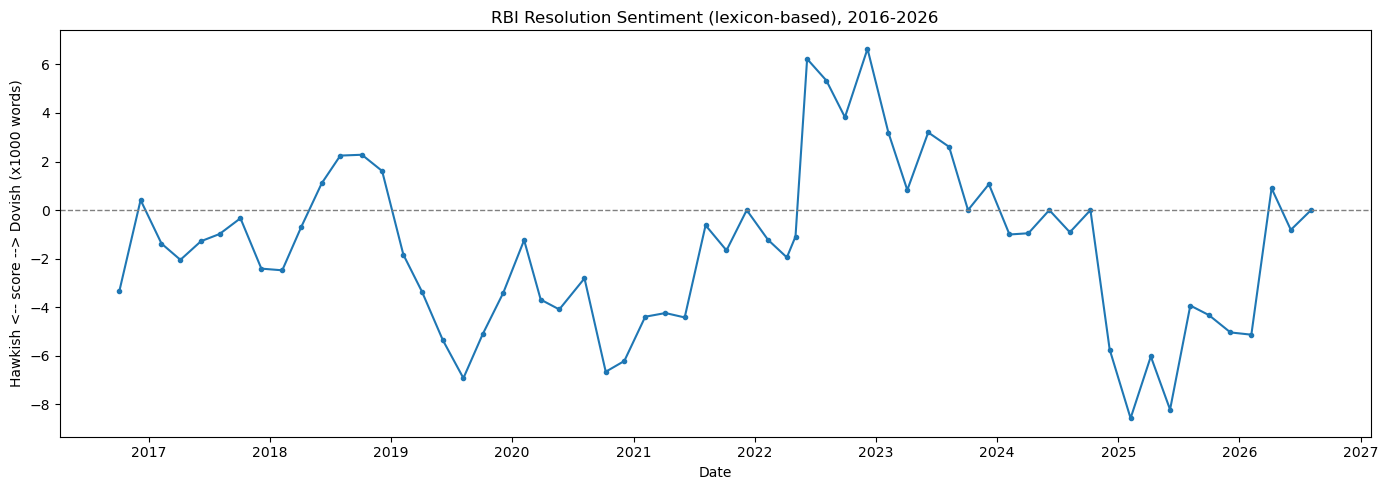

In [7]:
import matplotlib.pyplot as plt

resolutions = scored[scored["doc_type"] == "resolution"].sort_values("listed_date")

plt.figure(figsize=(14, 5))
plt.plot(resolutions["listed_date"], resolutions["lexicon_score_x1000"], marker="o", markersize=3)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("RBI Resolution Sentiment (lexicon-based), 2016-2026")
plt.ylabel("Hawkish <-- score --> Dovish (x1000 words)")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lexicon_sentiment_timeseries.png", dpi=150)
plt.show()

---

The September 2022 Resolution scores +3.82 (hawkish) and the early-2021 Resolutions score approximately −4.3 (dovish), both in the theoretically correct direction. Baseline 2 (FinBERT, sentence-level) is computed in `04_finbert_scoring.ipynb`.